# EDA — NDVI-AVHRR (verdor vegetal, 1981+)

Fuente satelital de **verdor de la vegetación** que se probó como feature extra en
[`experiments/05`](../experiments/05_features_nuevas.ipynb). La hipótesis: si una plaga
o granizo arrasa un lote, el clima no lo registra pero el NDVI (índice de vegetación)
sí debería — podría capturar parte del ~70% de anomalías "clima normal / rinde anómalo"
del techo estructural.

**Fuente:** NOAA CDR NDVI — AVHRR v5 (1981–2013) + VIIRS v1 (2014+), ~5 km, promediado
por departamento (FAO GAUL nivel 2) vía Google Earth Engine. Se usa AVHRR (y no MODIS,
que arranca en 2000) para **no recortar la historia del train**. Columnas
`ndvi_avhrr_<mes>` (Sep–Mar), mapeadas a campaña.

Este notebook mira la señal cruda: cobertura, estacionalidad, y si el NDVI **separa**
las campañas anómalas de las normales.

In [1]:
import os, sys, warnings
if os.path.basename(os.getcwd()) == "eda":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110

from src.config import MESES, PANEL_NDVI_PATH
from src import data as cdata

# Panel aumentado con NDVI-AVHRR + etiqueta proxy (mismo pipeline que los experimentos)
panel = cdata.load_panel(PANEL_NDVI_PATH, use_ndvi=True)
panel = cdata.compute_z_rinde(panel)

AVHRR = [f"ndvi_avhrr_{m}" for m in MESES if f"ndvi_avhrr_{m}" in panel.columns]
print("meses NDVI-AVHRR:", [c.replace('ndvi_avhrr_', '') for c in AVHRR])
print("campañas:", int(panel.campania_inicio.min()), "→", int(panel.campania_inicio.max()))

[data] dedup panel: 28683 → 21418 filas (7265 duplicados espurios por lat/lon eliminados)


meses NDVI-AVHRR: ['sep', 'oct', 'nov', 'dic', 'ene', 'feb', 'mar']
campañas: 1981 → 2024


## 1 · Cobertura
A diferencia del NDVI-MODIS del panel original (~45% NaN, solo 2002+), el AVHRR cubre
casi toda la historia — por eso es la prueba *justa* del efecto del verdor.

In [2]:
cov = pd.DataFrame({
    "col": AVHRR,
    "nan_%": [round(panel[c].isna().mean()*100, 1) for c in AVHRR],
    "min": [round(panel[c].min(), 3) for c in AVHRR],
    "mediana": [round(panel[c].median(), 3) for c in AVHRR],
    "max": [round(panel[c].max(), 3) for c in AVHRR],
}).set_index("col")
cov

,nan_%,min,mediana,max
col,,,,
ndvi_avhrr_sep,1.0,-0.035,0.495,0.920
ndvi_avhrr_oct,3.1,0.149,0.561,0.893
ndvi_avhrr_nov,3.1,0.158,0.588,0.888
ndvi_avhrr_dic,3.1,0.003,0.604,0.893
ndvi_avhrr_ene,1.0,0.182,0.638,0.917
ndvi_avhrr_feb,1.0,0.209,0.656,0.901
ndvi_avhrr_mar,1.0,0.216,0.653,0.910


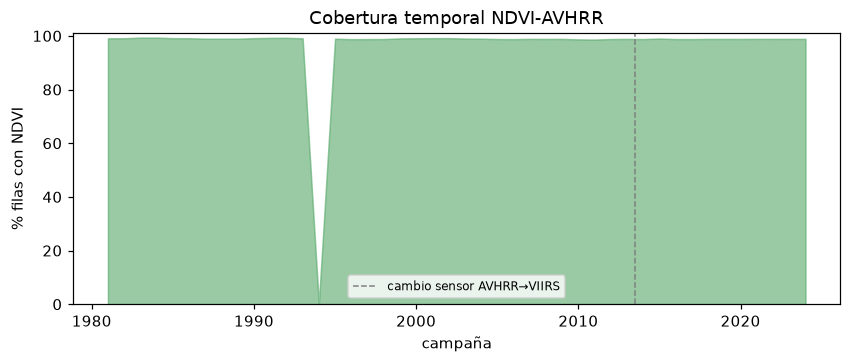

In [3]:
# Cobertura por año (fracción de filas con NDVI presente)
g = panel.assign(tiene=panel[AVHRR].notna().all(axis=1))
cob = g.groupby("campania_inicio")["tiene"].mean()
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.fill_between(cob.index, cob.values*100, color="#55A868", alpha=0.6)
ax.axvline(2013.5, color="gray", ls="--", lw=1, label="cambio sensor AVHRR→VIIRS")
ax.set_ylabel("% filas con NDVI"); ax.set_xlabel("campaña"); ax.set_ylim(0, 101)
ax.set_title("Cobertura temporal NDVI-AVHRR"); ax.legend(fontsize=8); plt.show()

> El cambio de sensor AVHRR→VIIRS en 2013/14 introduce un pequeño *offset*; la
> normalización por departamento absorbe parte, pero es una limitación a tener presente.

## 2 · Estacionalidad del verdor
Ciclo del cultivo: el NDVI arranca bajo en la siembra (Sep–Oct), pico en pleno verano
(Dic–Ene) y baja hacia la cosecha (Mar). Debería verse esa curva.

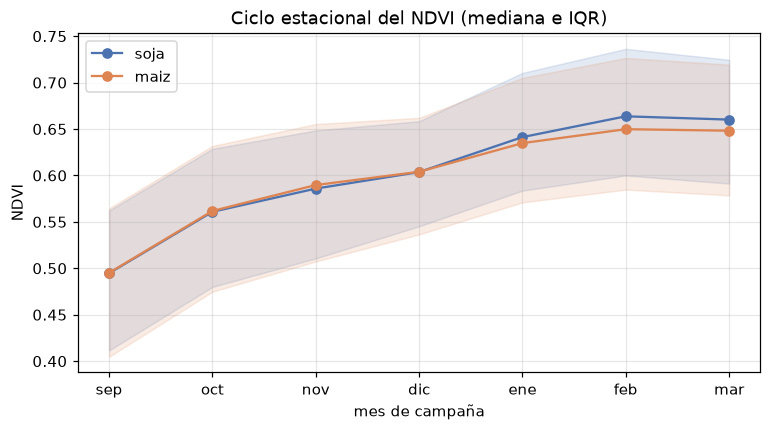

In [4]:
meses_lbl = [c.replace("ndvi_avhrr_", "") for c in AVHRR]
orden = ["sep", "oct", "nov", "dic", "ene", "feb", "mar"]
idx = [meses_lbl.index(m) for m in orden if m in meses_lbl]
cols_ord = [AVHRR[i] for i in idx]; lbl_ord = [meses_lbl[i] for i in idx]
fig, ax = plt.subplots(figsize=(8, 4))
for cult, color in [("soja", "#4C72B0"), ("maiz", "#DD8452")]:
    sub = panel[panel.cultivo == cult]
    med = [sub[c].median() for c in cols_ord]
    q1 = [sub[c].quantile(0.25) for c in cols_ord]
    q3 = [sub[c].quantile(0.75) for c in cols_ord]
    ax.plot(lbl_ord, med, "-o", color=color, label=cult)
    ax.fill_between(range(len(lbl_ord)), q1, q3, color=color, alpha=0.15)
ax.set_ylabel("NDVI"); ax.set_xlabel("mes de campaña")
ax.set_title("Ciclo estacional del NDVI (mediana e IQR)"); ax.legend(); ax.grid(alpha=0.3); plt.show()

## 3 · La pregunta clave: ¿el NDVI separa anómalas de normales?
Comparamos el NDVI de campañas **anómalas** (`z_rinde < −1.5`) vs **normales**, por mes.
Si el verdor viera lo que el clima no ve, las anómalas deberían tener NDVI más bajo
(vegetación estresada). Foco en soja.

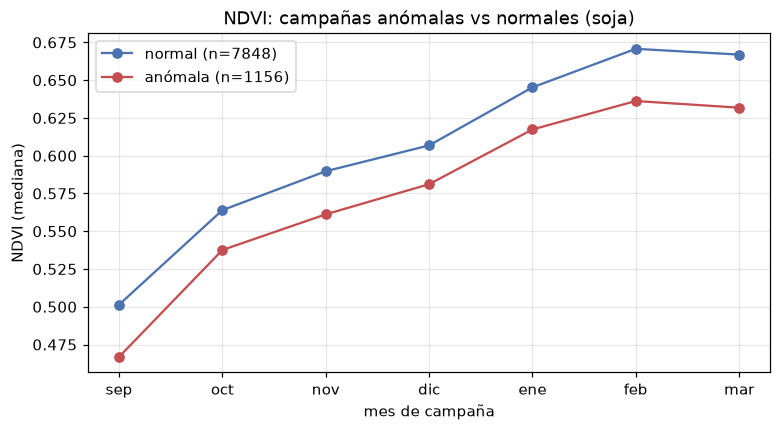

mes   Δmediana   Cohen_d
sep     -0.035   -0.20
oct     -0.026   -0.19
nov     -0.029   -0.28
dic     -0.026   -0.33
ene     -0.028   -0.36
feb     -0.035   -0.37
mar     -0.035   -0.34


In [5]:
sub = panel[(panel.cultivo == "soja") & panel[cols_ord].notna().all(axis=1)].copy()
sub = sub.dropna(subset=["anomalia"])
norm = sub[sub.anomalia == 0]; anom = sub[sub.anomalia == 1]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lbl_ord, [norm[c].median() for c in cols_ord], "-o", color="#4C72B0", label=f"normal (n={len(norm)})")
ax.plot(lbl_ord, [anom[c].median() for c in cols_ord], "-o", color="#C44E52", label=f"anómala (n={len(anom)})")
ax.set_ylabel("NDVI (mediana)"); ax.set_xlabel("mes de campaña")
ax.set_title("NDVI: campañas anómalas vs normales (soja)"); ax.legend(); ax.grid(alpha=0.3); plt.show()

# Tamaño del efecto por mes (diferencia estandarizada, Cohen's d)
print("mes   Δmediana   Cohen_d")
for c, m in zip(cols_ord, lbl_ord):
    a, n = anom[c].dropna(), norm[c].dropna()
    pooled = np.sqrt((a.var() + n.var()) / 2)
    d = (a.mean() - n.mean()) / pooled if pooled else 0
    print(f"{m:4s}  {a.median()-n.median():+8.3f}   {d:+.2f}")

**Lectura:** hay una separación en la dirección esperada (las anómalas tienen NDVI
algo más bajo en verano) pero el tamaño del efecto es **chico** — mucho menor que la
firma climática de sequía, y las distribuciones se solapan fuerte. El NDVI aporta sobre
todo información **redundante** con el clima (una sequía deprime lluvia *y* verdor a la
vez), no una señal nueva sobre las anomalías invisibles.

## 4 · ¿Redundante con el clima? Correlación NDVI ↔ precipitación
Si el NDVI de verano ya está explicado por la lluvia, agregar ambas al modelo no suma
información — solo diluye. Correlación NDVI-Ene vs precipitación NASA-Ene:

In [6]:
m = panel[(panel.cultivo == "soja")].copy()
pairs = [("ndvi_avhrr_ene", "prectotcorr_ene"), ("ndvi_avhrr_feb", "prectotcorr_feb"),
         ("ndvi_avhrr_dic", "prectotcorr_dic")]
for ndvi_c, prec_c in pairs:
    if ndvi_c in m and prec_c in m:
        sub = m[[ndvi_c, prec_c]].dropna()
        r = sub[ndvi_c].corr(sub[prec_c])
        print(f"corr({ndvi_c}, {prec_c}) = {r:+.2f}")

corr(ndvi_avhrr_ene, prectotcorr_ene) = +0.21
corr(ndvi_avhrr_feb, prectotcorr_feb) = +0.14
corr(ndvi_avhrr_dic, prectotcorr_dic) = +0.24


## 5 · Conclusión del EDA
- **Cobertura completa 1981–2024** (a diferencia del MODIS 2002+): es la prueba justa
  del verdor, sin recortar el train. Ojo con el cambio de sensor en 2013/14.
- **Estacionalidad correcta** (pico en verano) → la señal es real, no ruido.
- **Separa poco** las anómalas de las normales, y de forma **redundante** con la lluvia.

Esto anticipa el resultado experimental: en [`experiments/05`](../experiments/05_features_nuevas.ipynb)
el NDVI **no supera al modelo base** (perjudica al VAE por dilución del `recon_prob`,
neutro para el IForest). Refuerza el techo estructural: si ni el verdor de la planta
marca esas anomalías de rinde, no son fallas biofísicas observables por satélite.